# Panel estimator event studies

Interactive comparison of trex panel estimators on a synthetic latent-factor design and the California Proposition 99 smoking dataset. The plots and tables below are embedded notebook outputs; no external output files are required.

In [1]:
from pathlib import Path
import csv, math, random

import torch
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from trex.panel import SyntheticDID, did_estimate, matrix_completion_estimate

METHODS = [
    'DID', 'Synthetic Control (SC)', 'Synthetic DID (SDID)', 'Time Weighted DID',
    'SDID (No Intercept)', 'SC with FEs (DIFP)', 'Matrix Completion',
    'SC (Regularized)', 'DIFP (Regularized)'
]

In [2]:
# Helper functions: DGP/data loading, estimator fitting, event curves, and placebo SEs.
# These are defined once so the dataset sections below can be run and modified interactively.

REPO = Path('/Users/alal/Desktop/code/trex')
NB = REPO / 'nb/panel_estimators_event_study.ipynb'
METHODS = [
    'DID', 'Synthetic Control (SC)', 'Synthetic DID (SDID)', 'Time Weighted DID',
    'SDID (No Intercept)', 'SC with FEs (DIFP)', 'Matrix Completion',
    'SC (Regularized)', 'DIFP (Regularized)'
]

def make_synthetic_factor_panel(seed=123, n=100, n1=20, t=50, t0=40, rank=3, tau=-2.0):
    torch.manual_seed(seed)
    dtype = torch.float64
    n0 = n - n1
    F = torch.randn(n, rank, dtype=dtype)
    order = torch.argsort(F[:, 0])
    control_idx = order[:n0]
    treated_idx = order[n0:]
    F = F[torch.cat([control_idx, treated_idx])]
    time = torch.linspace(-1.0, 1.0, t, dtype=dtype)
    Lambda = torch.stack([2.0 * time, torch.sin(math.pi * time), (time + 0.25).pow(2)], dim=1)[:, :rank]
    unit_fe = 0.8 * torch.randn(n, dtype=dtype)
    time_fe = 1.5 * time + 0.5 * torch.sin(2 * math.pi * (time + 1) / 2)
    Y0 = F @ Lambda.T + unit_fe[:, None] + time_fe[None, :] + 0.25 * torch.randn(n, t, dtype=dtype)
    Y = Y0.clone()
    Y[n0:, t0:] += tau
    return Y, n0, t0, tau

def load_california_prop99(path=REPO.parent / '_refs/synthdid/data/california_prop99.csv'):
    rows = []
    with path.open(newline='') as f:
        reader = csv.DictReader(f, delimiter=';')
        for row in reader:
            rows.append((row['State'], int(row['Year']), float(row['PacksPerCapita']), int(row['treated'])))
    states_all = sorted({r[0] for r in rows})
    treated_states = sorted({r[0] for r in rows if r[3] == 1})
    states = [s for s in states_all if s not in treated_states] + treated_states
    years = sorted({r[1] for r in rows})
    by_key = {(s, y): (packs, treated) for s, y, packs, treated in rows}
    Y = torch.empty((len(states), len(years)), dtype=torch.float64)
    W = torch.empty_like(Y, dtype=torch.bool)
    for i, state in enumerate(states):
        for j, year in enumerate(years):
            Y[i, j], W[i, j] = by_key[(state, year)]
    return Y, int((~W.any(dim=1)).sum()), int((~W.any(dim=0)).sum()), states, years

def fit_method(Y, N0, T0, method, sdid_kwargs=None, mc_kwargs=None):
    sdid_kwargs = dict(sdid_kwargs or {})
    mc_kwargs = dict(mc_kwargs or {})
    N, T = Y.shape
    uniform_lambda = torch.full((T0,), 1.0 / T0, dtype=Y.dtype)
    uniform_omega = torch.full((N0,), 1.0 / N0, dtype=Y.dtype)
    reg_eta = ((N - N0) * (T - T0)) ** 0.25
    if method == 'DID':
        return {'estimate': did_estimate(Y, N0, T0), 'omega': uniform_omega, 'lambda': uniform_lambda, 'kind': 'weighted'}
    if method == 'Synthetic Control (SC)':
        r = SyntheticDID(eta_omega=1e-6, lambda_weights=torch.zeros(T0, dtype=Y.dtype), update_lambda=False, omega_intercept=False, **sdid_kwargs).fit(Y, N0, T0).result_
        return {'estimate': r.estimate, 'omega': r.omega, 'lambda': r.lambda_, 'kind': 'weighted'}
    if method == 'Synthetic DID (SDID)':
        r = SyntheticDID(**sdid_kwargs).fit(Y, N0, T0).result_
        return {'estimate': r.estimate, 'omega': r.omega, 'lambda': r.lambda_, 'kind': 'weighted'}
    if method == 'Time Weighted DID':
        r = SyntheticDID(omega=uniform_omega, update_omega=False, **sdid_kwargs).fit(Y, N0, T0).result_
        return {'estimate': r.estimate, 'omega': r.omega, 'lambda': r.lambda_, 'kind': 'weighted'}
    if method == 'SDID (No Intercept)':
        r = SyntheticDID(omega_intercept=False, **sdid_kwargs).fit(Y, N0, T0).result_
        return {'estimate': r.estimate, 'omega': r.omega, 'lambda': r.lambda_, 'kind': 'weighted'}
    if method == 'SC with FEs (DIFP)':
        r = SyntheticDID(lambda_weights=uniform_lambda, update_lambda=False, eta_omega=1e-6, **sdid_kwargs).fit(Y, N0, T0).result_
        return {'estimate': r.estimate, 'omega': r.omega, 'lambda': r.lambda_, 'kind': 'weighted'}
    if method == 'SC (Regularized)':
        r = SyntheticDID(eta_omega=reg_eta, lambda_weights=torch.zeros(T0, dtype=Y.dtype), update_lambda=False, omega_intercept=False, **sdid_kwargs).fit(Y, N0, T0).result_
        return {'estimate': r.estimate, 'omega': r.omega, 'lambda': r.lambda_, 'kind': 'weighted'}
    if method == 'DIFP (Regularized)':
        r = SyntheticDID(lambda_weights=uniform_lambda, update_lambda=False, **sdid_kwargs).fit(Y, N0, T0).result_
        return {'estimate': r.estimate, 'omega': r.omega, 'lambda': r.lambda_, 'kind': 'weighted'}
    if method == 'Matrix Completion':
        tau, model = matrix_completion_estimate(Y, N0, T0, **mc_kwargs)
        return {'estimate': tau, 'model': model, 'kind': 'mc'}
    raise ValueError(method)

def event_curve(Y, N0, T0, fit):
    N, T = Y.shape
    N1 = N - N0
    if fit['kind'] == 'weighted':
        omega = fit['omega']; lam = fit['lambda']
        lambda_synth = torch.cat([lam, torch.zeros(T - T0, dtype=Y.dtype)])
        omega_synth = torch.cat([omega, torch.zeros(N1, dtype=Y.dtype)])
        omega_target = torch.cat([torch.zeros(N0, dtype=Y.dtype), torch.full((N1,), 1.0 / N1, dtype=Y.dtype)])
        offset = (omega_target - omega_synth) @ Y @ lambda_synth
        return omega_target @ Y - (omega_synth @ Y + offset)
    return Y[N0:, :].mean(dim=0) - fit['model'].predict()[N0:, :].mean(dim=0)

def placebo_se(Y, N0, T0, method, reps=25, seed=22, sdid_kwargs=None, mc_kwargs=None):
    rng = random.Random(seed)
    N1 = Y.shape[0] - N0
    controls = list(range(N0))
    draws = [[i] for i in controls] if N1 == 1 and len(controls) <= 80 else [rng.sample(controls, N1) for _ in range(reps)]
    vals = []
    for treated in draws:
        pseudo_controls = [i for i in controls if i not in treated]
        idx = pseudo_controls + list(treated)
        try:
            val = fit_method(Y[idx, :], len(pseudo_controls), T0, method, sdid_kwargs=sdid_kwargs, mc_kwargs=mc_kwargs)['estimate']
            if torch.isfinite(val): vals.append(float(val))
        except Exception:
            pass
    return float(torch.tensor(vals, dtype=torch.float64).std(unbiased=True)) if len(vals) > 1 else float('nan')

def analyze(Y, N0, T0):
    sdid = {'maxiter': 10_000, 'min_decrease': 1e-5, 'sparsify': True}
    mc = {'lambda_fraction': 0.15, 'maxiter': 400, 'tol': 1e-7}
    fits = {m: fit_method(Y, N0, T0, m, sdid_kwargs=sdid, mc_kwargs=mc) for m in METHODS}
    rows = []
    for m in METHODS:
        if m == 'Matrix Completion':
            se = placebo_se(Y, N0, T0, m, reps=12, sdid_kwargs={**sdid, 'maxiter': 3000}, mc_kwargs={'lambda_fraction': 0.15, 'maxiter': 50, 'tol': 1e-5})
        else:
            se = placebo_se(Y, N0, T0, m, reps=25, sdid_kwargs={**sdid, 'maxiter': 3000}, mc_kwargs={'lambda_fraction': 0.15, 'maxiter': 50, 'tol': 1e-5})
        rows.append((m, float(fits[m]['estimate']), se))
    return fits, rows

def rows_to_md(rows):
    lines = ['| Method | Estimate | Placebo SE |', '|---|---:|---:|']
    lines += [f'| {m} | {e:.3f} | {se:.3f} |' for m,e,se in rows]
    return '\n'.join(lines)

def fig_to_png_b64(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=160, bbox_inches='tight')
    plt.close(fig)
    return base64.b64encode(buf.getvalue()).decode('ascii')

def event_fig(Y, N0, T0, fits, title, x_labels=None, true_tau=None):
    fig, ax = plt.subplots(figsize=(11, 6))
    xs = list(range(Y.shape[1])) if x_labels is None else x_labels
    for m in METHODS:
        curve = event_curve(Y, N0, T0, fits[m]).detach().numpy()
        lw = 2.4 if m in ['Synthetic DID (SDID)', 'Matrix Completion', 'DID'] else 1.2
        alpha = 0.95 if m in ['Synthetic DID (SDID)', 'Matrix Completion', 'DID'] else 0.65
        ax.plot(xs, curve, label=m, linewidth=lw, alpha=alpha)
    ax.axvline(xs[T0], color='black', linestyle='--', linewidth=1)
    ax.axhline(0, color='gray', linewidth=0.8)
    if true_tau is not None:
        ax.axhline(true_tau, color='black', linestyle=':', linewidth=1.2, label=f'true ATT = {true_tau:g}')
    ax.set(title=title, xlabel='time', ylabel='estimated effect curve')
    ax.legend(ncol=2, fontsize=8)
    return fig

def estimate_fig(rows, title, true_tau=None):
    fig, ax = plt.subplots(figsize=(10, 4.8))
    labels = [r[0] for r in rows]
    est = [r[1] for r in rows]
    ses = [r[2] for r in rows]
    y = list(range(len(rows)))
    ax.errorbar(est, y, xerr=[1.96*s if math.isfinite(s) else 0 for s in ses], fmt='o', capsize=3)
    if true_tau is not None: ax.axvline(true_tau, color='black', linestyle=':', label='true ATT')
    ax.axvline(0, color='gray', linewidth=0.8)
    ax.set_yticks(y, labels)
    ax.invert_yaxis()
    ax.set(title=title, xlabel='ATT estimate with placebo 95% interval')
    return fig


## 1. Synthetic factor panel

100 units, 20 treated from period 40 of 50. Treated units are selected on latent factors, so parallel trends is false by construction.

In [3]:
Y_syn, N0_syn, T0_syn, true_tau = make_synthetic_factor_panel()
print(f'Synthetic factor panel: N={Y_syn.shape[0]}, T={Y_syn.shape[1]}, N0={N0_syn}, N1={Y_syn.shape[0]-N0_syn}, T0={T0_syn}, true ATT={true_tau}')

Synthetic factor panel: N=100, T=50, N0=80, N1=20, T0=40, true ATT=-2.0


In [4]:
fits_syn, rows_syn = analyze(Y_syn, N0_syn, T0_syn)
display(Markdown(rows_to_md(rows_syn)))

| Method | Estimate | Placebo SE |
|---|---:|---:|
| DID | 1.895 | 0.510 |
| Synthetic Control (SC) | 0.014 | 0.161 |
| Synthetic DID (SDID) | -0.967 | 0.195 |
| Time Weighted DID | -1.134 | 0.229 |
| SDID (No Intercept) | -0.872 | 0.167 |
| SC with FEs (DIFP) | 0.123 | 0.157 |
| Matrix Completion | 0.021 | 0.353 |
| SC (Regularized) | -0.150 | 0.228 |
| DIFP (Regularized) | -0.114 | 0.266 |

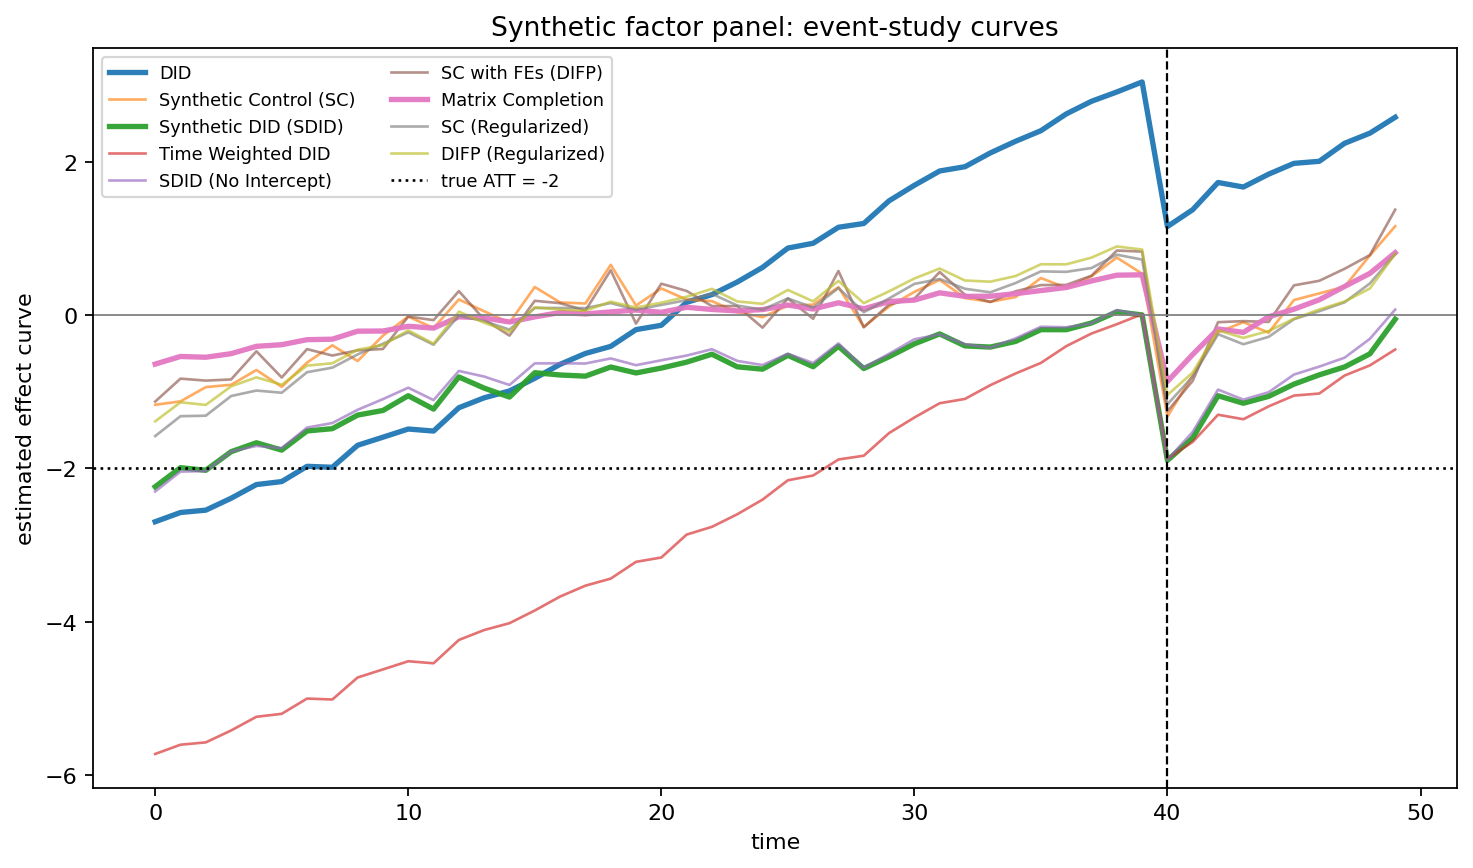

In [5]:
fig = event_fig(Y_syn, N0_syn, T0_syn, fits_syn, 'Synthetic factor panel: event-study curves', true_tau=true_tau)
plt.show()

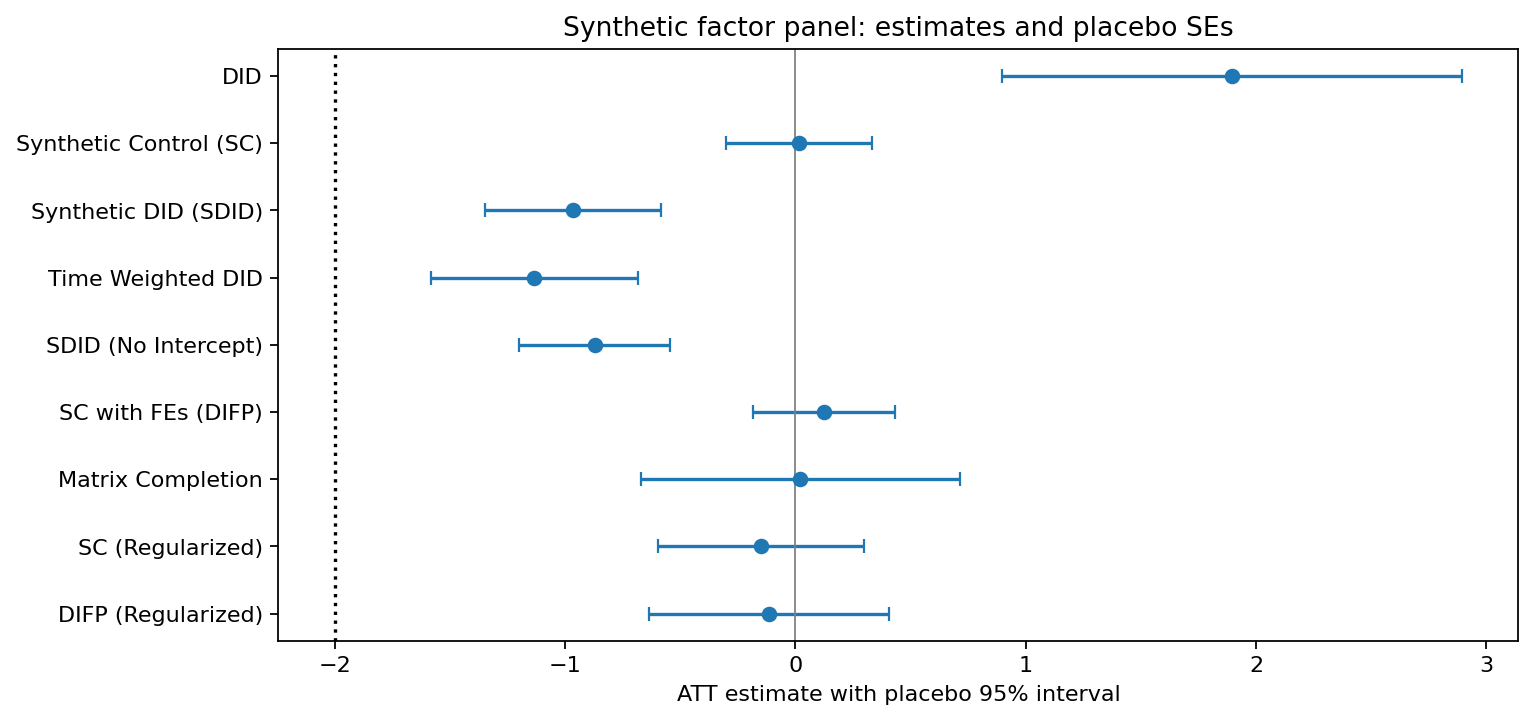

In [6]:
fig = estimate_fig(rows_syn, 'Synthetic factor panel: estimates and placebo SEs', true_tau=true_tau)
plt.show()

## 2. California smoking dataset

California Proposition 99 panel from the synthdid reference repository.

In [7]:
Y_ca, N0_ca, T0_ca, states, years = load_california_prop99()
print(f'California smoking: N={Y_ca.shape[0]}, T={Y_ca.shape[1]}, N0={N0_ca}, treated={states[N0_ca:]}, treatment year={years[T0_ca]}')

California smoking: N=39, T=31, N0=38, treated=['California'], treatment year=1989


In [8]:
fits_ca, rows_ca = analyze(Y_ca, N0_ca, T0_ca)
display(Markdown(rows_to_md(rows_ca)))

| Method | Estimate | Placebo SE |
|---|---:|---:|
| DID | -27.349 | 17.519 |
| Synthetic Control (SC) | -19.620 | 10.766 |
| Synthetic DID (SDID) | -15.604 | 9.492 |
| Time Weighted DID | -19.772 | 10.063 |
| SDID (No Intercept) | -18.751 | 10.306 |
| SC with FEs (DIFP) | -11.105 | 10.199 |
| Matrix Completion | -20.381 | 11.954 |
| SC (Regularized) | -21.716 | 10.999 |
| DIFP (Regularized) | -16.121 | 9.853 |

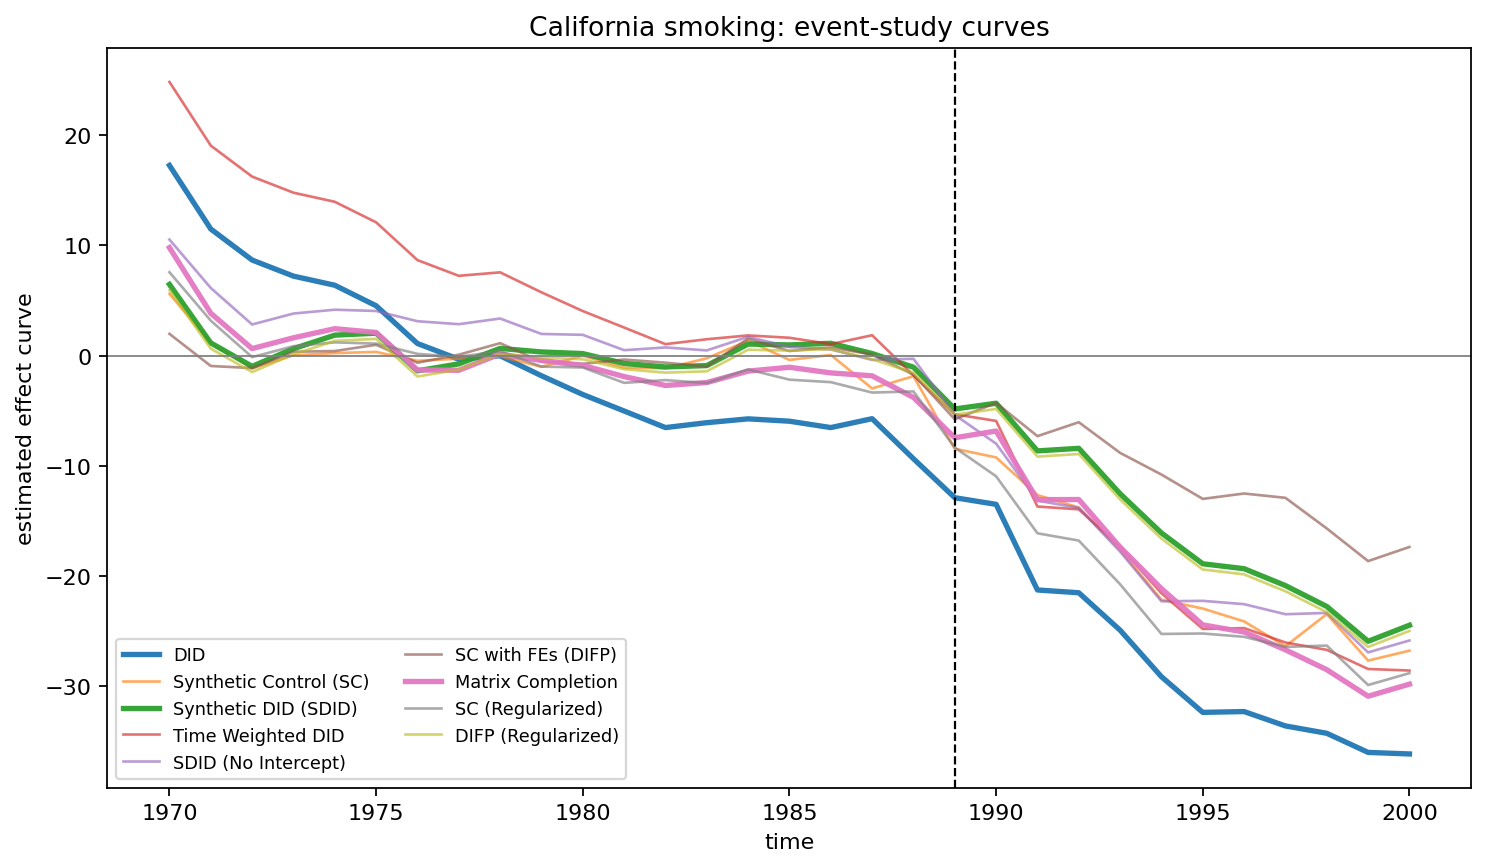

In [9]:
fig = event_fig(Y_ca, N0_ca, T0_ca, fits_ca, 'California smoking: event-study curves', x_labels=years)
plt.show()

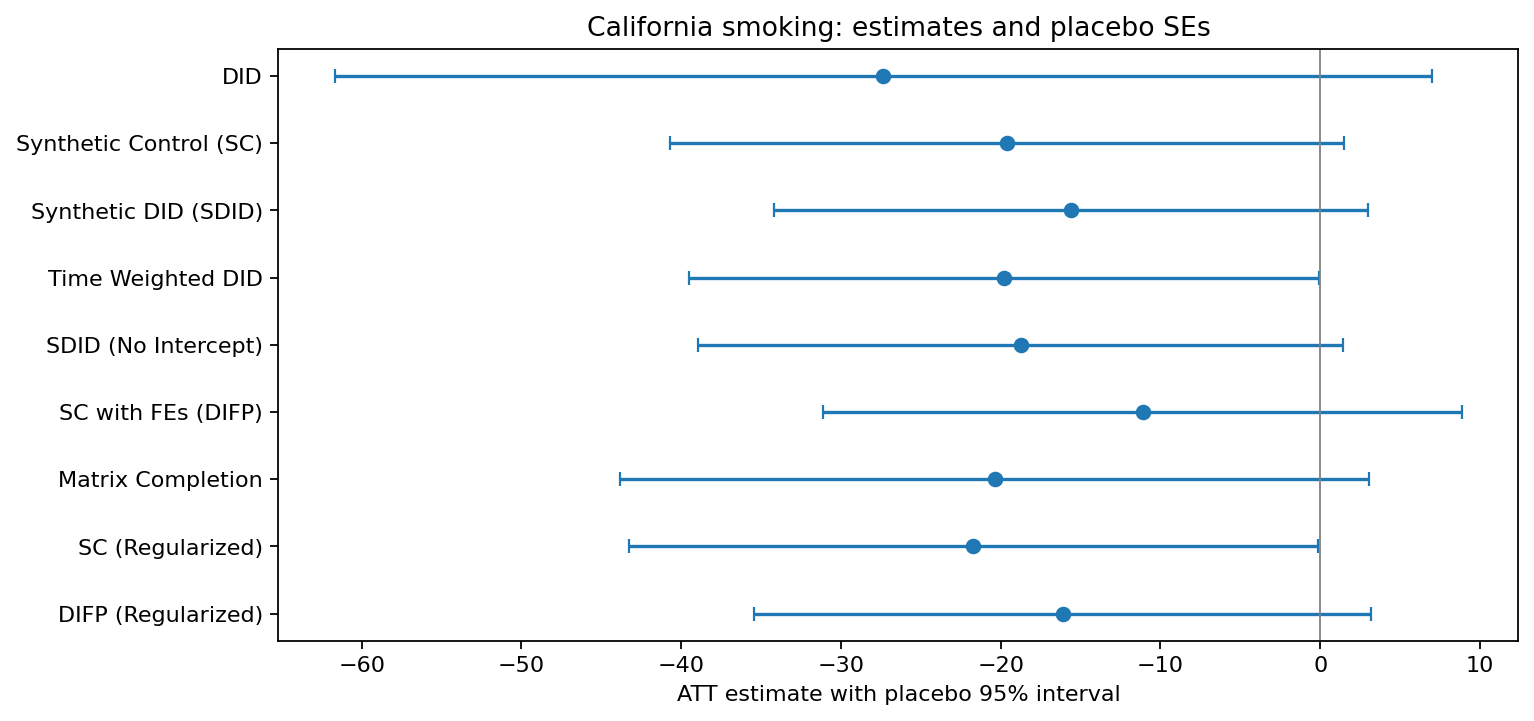

In [10]:
fig = estimate_fig(rows_ca, 'California smoking: estimates and placebo SEs')
plt.show()